<a href="https://colab.research.google.com/github/probml/probml-notebooks/blob/main/notebooks/student_pgm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The student Bayes net

For more info: https://github.com/pgmpy/pgmpy_notebook/blob/master/notebooks/2.%20Bayesian%20Networks.ipynb

### 1. Setup

Run the cell below once. It installs all required packages automatically.

In [3]:
import subprocess, sys, importlib, collections, collections.abc

def _pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *args], check=True)

# probml-utils: install directly from GitHub without heavy optional deps
# (jax/jaxlib in its requirements.txt fail to build on Python 3.10+)
_pip("git+https://github.com/probml/probml-utils.git", "--no-deps")

# Everything else the notebook actually uses
_pip("pgmpy", "graphviz", "causalgraphicalmodels", "numpy", "pandas")

# causalgraphicalmodels uses collections.Iterable, removed in Python 3.10.
# Restore it before the package is imported.
if not hasattr(collections, "Iterable"):
    collections.Iterable = collections.abc.Iterable

print("Setup complete.")

Setup complete.


import probml_utils.pgmpy_utils as pgm
from causalgraphicalmodels import CausalGraphicalModel
import pgmpy
import numpy as np
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork as BayesianNetwork  # renamed in pgmpy >= 1.1
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

In [7]:
import probml_utils.pgmpy_utils as pgm
from causalgraphicalmodels import CausalGraphicalModel
# Note: If you are using python 3.3 or greater, you will need to update collections to collections.abc
import pgmpy
import numpy as np
import pandas as pd
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination

# Model



<img src="https://user-images.githubusercontent.com/4632336/118884310-21bec180-b8ab-11eb-81cf-481553c21d8a.png?raw=true">


In [8]:
# Define the model structure

model = DiscreteBayesianNetwork([('Diff', 'Grade'), ('Intel', 'Grade'), ('Grade', 'Letter'), ('Intel', 'SAT')])


## Basic CPTs

In [10]:
# Defining individual CPDs.
cpd_d = TabularCPD(variable="Diff", variable_card=2, values=[[0.6], [0.4]])
cpd_i = TabularCPD(variable="Intel", variable_card=2, values=[[0.7], [0.3]])

# The representation of CPD in pgmpy is a bit different than the CPD shown in the above picture. In pgmpy the colums
# are the evidences and rows are the states of the variable. So the grade CPD is represented like this:
#
#    +---------+---------+---------+---------+---------+
#    | diff    | intel_0 | intel_0 | intel_1 | intel_1 |
#    +---------+---------+---------+---------+---------+
#    | intel   | diff_0  | diff_1  | diff_0  | diff_1  |
#    +---------+---------+---------+---------+---------+
#    | grade_0 | 0.3     | 0.05    | 0.9     | 0.5     |
#    +---------+---------+---------+---------+---------+
#    | grade_1 | 0.4     | 0.25    | 0.08    | 0.3     |
#    +---------+---------+---------+---------+---------+
#    | grade_2 | 0.3     | 0.7     | 0.02    | 0.2     |
#    +---------+---------+---------+---------+---------+

cpd_g = TabularCPD(
    variable="Grade",
    variable_card=3,
    values=[[0.3, 0.05, 0.9, 0.5], [0.4, 0.25, 0.08, 0.3], [0.3, 0.7, 0.02, 0.2]],
    evidence=["Intel", "Diff"],
    evidence_card=[2, 2],
)

cpd_l = TabularCPD(
    variable="Letter",
    variable_card=2,
    values=[[0.1, 0.4, 0.99], [0.9, 0.6, 0.01]],
    evidence=["Grade"],
    evidence_card=[3],
)

cpd_s = TabularCPD(
    variable="SAT", variable_card=2, values=[[0.95, 0.2], [0.05, 0.8]], evidence=["Intel"], evidence_card=[2]
)

# Associating the CPDs with the network
model.add_cpds(cpd_d, cpd_i, cpd_g, cpd_l, cpd_s)

# check_model checks for the network structure and CPDs and verifies that the CPDs are correctly
# defined and sum to 1.
model.check_model()

True

In [11]:
print(model.get_cpds("Grade"))

+----------+----------+----------+----------+----------+
| Intel    | Intel(0) | Intel(0) | Intel(1) | Intel(1) |
+----------+----------+----------+----------+----------+
| Diff     | Diff(0)  | Diff(1)  | Diff(0)  | Diff(1)  |
+----------+----------+----------+----------+----------+
| Grade(0) | 0.3      | 0.05     | 0.9      | 0.5      |
+----------+----------+----------+----------+----------+
| Grade(1) | 0.4      | 0.25     | 0.08     | 0.3      |
+----------+----------+----------+----------+----------+
| Grade(2) | 0.3      | 0.7      | 0.02     | 0.2      |
+----------+----------+----------+----------+----------+


## CPDs with names states

In [12]:
# CPDs can also be defined using the state names of the variables. If the state names are not provided
# like in the previous example, pgmpy will automatically assign names as: 0, 1, 2, ....

cpd_d_sn = TabularCPD(variable="Diff", variable_card=2, values=[[0.6], [0.4]], state_names={"Diff": ["Easy", "Hard"]})
cpd_i_sn = TabularCPD(variable="Intel", variable_card=2, values=[[0.7], [0.3]], state_names={"Intel": ["Low", "High"]})
cpd_g_sn = TabularCPD(
    variable="Grade",
    variable_card=3,
    values=[[0.3, 0.05, 0.9, 0.5], [0.4, 0.25, 0.08, 0.3], [0.3, 0.7, 0.02, 0.2]],
    evidence=["Intel", "Diff"],
    evidence_card=[2, 2],
    state_names={"Grade": ["A", "B", "C"], "Intel": ["Low", "High"], "Diff": ["Easy", "Hard"]},
)

cpd_l_sn = TabularCPD(
    variable="Letter",
    variable_card=2,
    values=[[0.1, 0.4, 0.99], [0.9, 0.6, 0.01]],
    evidence=["Grade"],
    evidence_card=[3],
    state_names={"Letter": ["Bad", "Good"], "Grade": ["A", "B", "C"]},
)

cpd_s_sn = TabularCPD(
    variable="SAT",
    variable_card=2,
    values=[[0.95, 0.2], [0.05, 0.8]],
    evidence=["Intel"],
    evidence_card=[2],
    state_names={"SAT": ["Bad", "Good"], "Intel": ["Low", "High"]},
)

# These defined CPDs can be added to the model. Since, the model already has CPDs associated to variables, it will
# show warning that pmgpy is now replacing those CPDs with the new ones.
model.add_cpds(cpd_d_sn, cpd_i_sn, cpd_g_sn, cpd_l_sn, cpd_s_sn)
model.check_model()

True

In [13]:
# Printing a CPD with it's state names defined.
print(model.get_cpds("Grade"))

+----------+------------+------------+-------------+-------------+
| Intel    | Intel(Low) | Intel(Low) | Intel(High) | Intel(High) |
+----------+------------+------------+-------------+-------------+
| Diff     | Diff(Easy) | Diff(Hard) | Diff(Easy)  | Diff(Hard)  |
+----------+------------+------------+-------------+-------------+
| Grade(A) | 0.3        | 0.05       | 0.9         | 0.5         |
+----------+------------+------------+-------------+-------------+
| Grade(B) | 0.4        | 0.25       | 0.08        | 0.3         |
+----------+------------+------------+-------------+-------------+
| Grade(C) | 0.3        | 0.7        | 0.02        | 0.2         |
+----------+------------+------------+-------------+-------------+


In [14]:
for cpd in model.get_cpds():
    print(cpd)

+------------+-----+
| Diff(Easy) | 0.6 |
+------------+-----+
| Diff(Hard) | 0.4 |
+------------+-----+
+-------------+-----+
| Intel(Low)  | 0.7 |
+-------------+-----+
| Intel(High) | 0.3 |
+-------------+-----+
+----------+------------+------------+-------------+-------------+
| Intel    | Intel(Low) | Intel(Low) | Intel(High) | Intel(High) |
+----------+------------+------------+-------------+-------------+
| Diff     | Diff(Easy) | Diff(Hard) | Diff(Easy)  | Diff(Hard)  |
+----------+------------+------------+-------------+-------------+
| Grade(A) | 0.3        | 0.05       | 0.9         | 0.5         |
+----------+------------+------------+-------------+-------------+
| Grade(B) | 0.4        | 0.25       | 0.08        | 0.3         |
+----------+------------+------------+-------------+-------------+
| Grade(C) | 0.3        | 0.7        | 0.02        | 0.2         |
+----------+------------+------------+-------------+-------------+
+--------------+----------+----------+----------

# Inference

In [15]:
# Doing exact inference using Variable Elimination
infer = VariableElimination(model)

## Posterior given Grade=C

In [16]:
evidence = {"Grade": "C"}
postD = infer.query(["Diff"], evidence=evidence).values
postI = infer.query(["Intel"], evidence=evidence).values

print("\n")
print("Pr(Difficulty=Hard|Grade=C) = {:0.2f}".format(postD[1]))
print("Pr(Intelligence=High|Grade=C) = {:0.2f}".format(postI[1]))



Pr(Difficulty=Hard|Grade=C) = 0.63
Pr(Intelligence=High|Grade=C) = 0.08


## Posterior given Grade=C, SAT=Good

In [17]:
evidence = {"Grade": "C", "SAT": "Good"}
postD = infer.query(["Diff"], evidence=evidence).values
postI = infer.query(["Intel"], evidence=evidence).values

print("\n")
print("Pr(Difficulty=Hard|Grade=C,SAT=Good) = {:0.2f}".format(postD[1]))
print("Pr(Intelligence=High|Grade=C,SAT=Good) = {:0.2f}".format(postI[1]))



Pr(Difficulty=Hard|Grade=C,SAT=Good) = 0.76
Pr(Intelligence=High|Grade=C,SAT=Good) = 0.58


# Visualization

## DAG

<class 'graphviz.graphs.Digraph'>


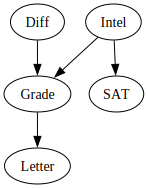

'student_pgm.pdf'

In [18]:
model2 = CausalGraphicalModel(nodes=model.nodes(), edges=model.edges())

dot = model2.draw()
print(type(dot))
display(dot)
dot.render(filename="student_pgm", format="pdf")
# creates student_pgm (a text file of the graph) and student_pgm.pdf

## CPTs

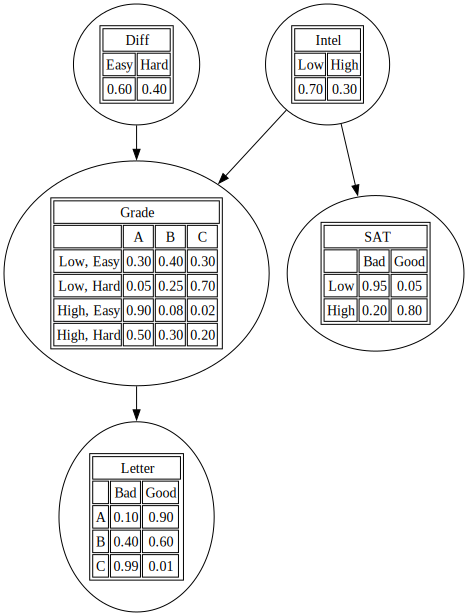

'student_pgm_with_cpt.pdf'

In [19]:
dot = pgm.visualize_model(model)
display(dot)
dot.render("student_pgm_with_cpt", format="pdf")

## Marginals

In [20]:
evidence = {"Grade": "C"}
marginals = pgm.get_marginals(model, evidence)
print(marginals)

{'Diff': array([0.37070938, 0.62929062]), 'Grade': array([0., 0., 1.]), 'Intel': array([0.92105263, 0.07894737]), 'Letter': array([0.99, 0.01]), 'SAT': array([0.89078947, 0.10921053])}


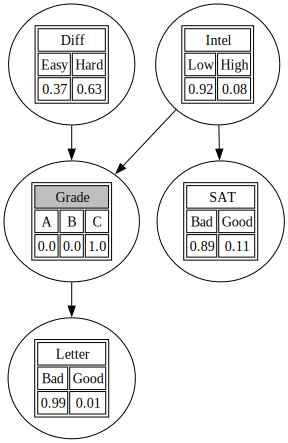

'student_pgm_marginals_given_grade.pdf'

In [21]:
dot = pgm.visualize_marginals(model, evidence, marginals)
display(dot)
dot.render("student_pgm_marginals_given_grade", format="pdf")

{'Diff': array([0.24044002, 0.75955998]), 'Grade': array([0., 0., 1.]), 'Intel': array([0.42168675, 0.57831325]), 'Letter': array([0.99, 0.01]), 'SAT': array([0., 1.])}


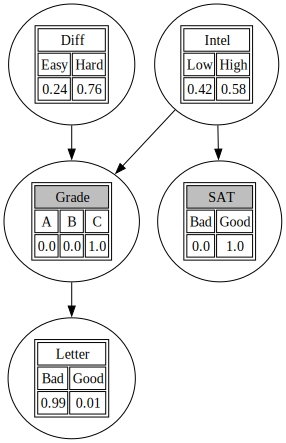

'student_pgm_marginals_given_grade_sat.pdf'

In [22]:
evidence = {"Grade": "C", "SAT": "Good"}
marginals = pgm.get_marginals(model, evidence)
print(marginals)

dot = pgm.visualize_marginals(model, evidence, marginals)
display(dot)
dot.render("student_pgm_marginals_given_grade_sat", format="pdf")

In [23]:
# Let's check the independencies in the model.
model.get_independencies()

(Grade ⟂ SAT | Intel)
(Letter ⟂ SAT | Grade)
(Diff ⟂ Intel)
(Diff ⟂ Letter | Grade)
(Diff ⟂ SAT)
(Intel ⟂ Letter | Grade)

In [49]:
# Sample data from the model
from pgmpy.sampling import BayesianModelSampling
data = BayesianModelSampling(model).forward_sample(int(10000))

Generating for node: Letter: 100%|██████████| 5/5 [00:00<00:00, 174.23it/s]


In [50]:
print('Data size: \n',data.size, '\n\nData head: \n',data.head(100))

Data size: 
 50000 

Data head: 
     Diff Grade Intel Letter   SAT
0   Easy     A  High   Good  Good
1   Hard     C   Low    Bad   Bad
2   Easy     C   Low    Bad   Bad
3   Hard     C   Low    Bad   Bad
4   Easy     B   Low   Good   Bad
..   ...   ...   ...    ...   ...
95  Easy     B   Low   Good   Bad
96  Easy     B   Low   Good   Bad
97  Easy     A  High    Bad  Good
98  Hard     C   Low    Bad  Good
99  Easy     C   Low    Bad   Bad

[100 rows x 5 columns]


## Hillclimb Algorithm (can be iffy)

In [ ]:
from pgmpy.estimators import HillClimbSearch, ExhaustiveSearch
from pgmpy.structure_score import get_scoring_method

# pgmpy >= 1.1 uses string aliases for scoring methods instead of class instances
# 'bic-d' = BIC for discrete data (replaces the old BicScore class)
est_hill = HillClimbSearch(data)
est_exhaustive = ExhaustiveSearch(data, scoring_method='bic-d')

best_hill_model = est_hill.estimate(scoring_method='bic-d')
best_exhaustive_model = est_exhaustive.estimate()

print("HillClimb edges: ", sorted(best_hill_model.edges()))
print("Exhaustive edges:", sorted(best_exhaustive_model.edges()))
print("True edges:      ", [('Diff','Grade'),('Grade','Letter'),('Intel','Grade'),('Intel','SAT')])

<class 'graphviz.graphs.Digraph'>


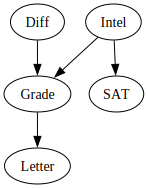

'student_pgm.pdf'

In [52]:
model3 = CausalGraphicalModel(nodes=best_exhaustive_model.nodes(), edges=best_exhaustive_model.edges())

dot = model3.draw()
print(type(dot))
display(dot)
dot.render(filename="student_pgm", format="pdf")

<class 'graphviz.graphs.Digraph'>


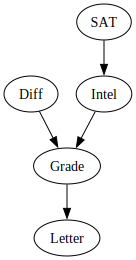

'student_pgm.pdf'

In [53]:
model4 = CausalGraphicalModel(nodes=best_hill_model.nodes(), edges=best_hill_model.edges())

dot = model4.draw()
print(type(dot))
display(dot)
dot.render(filename="student_pgm", format="pdf")

# How to fit model to data?

In [54]:
from pgmpy.estimators import MaximumLikelihoodEstimator
# assuming model is the Bayesian Network model you define and the data is the pandas DataFrame
network = DiscreteBayesianNetwork(best_exhaustive_model)
mle = MaximumLikelihoodEstimator(network, data)

# estimate the CPDs of the model and add to the model


for cpd in mle.get_parameters():
    network.add_cpds(cpd)


/var/folders/5l/qk11gnhn1zj0xtjp8dtgflv80000gn/T/ipykernel_5278/1393841423.py:4: FutureWarning: `pgmpy.estimators.MaximumLikelihoodEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteMLE` instead.
  mle = MaximumLikelihoodEstimator(network, data)


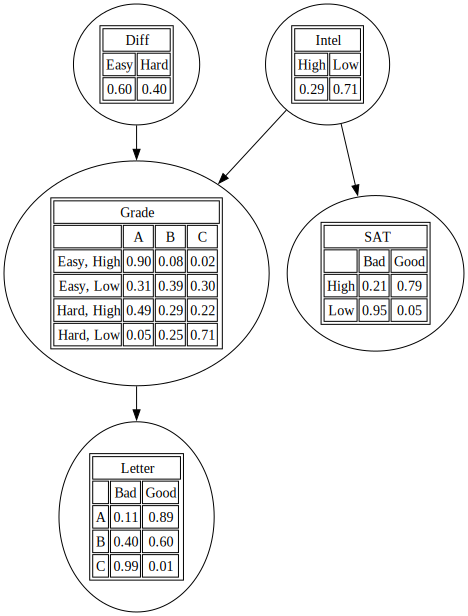

'student_pgm_with_cpt.pdf'

In [55]:
dot = pgm.visualize_model(network)
display(dot)
dot.render("student_pgm_with_cpt", format="pdf")

/var/folders/5l/qk11gnhn1zj0xtjp8dtgflv80000gn/T/ipykernel_5278/885855585.py:4: FutureWarning: `pgmpy.estimators.MaximumLikelihoodEstimator` is deprecated and will be removed in v1.3.0. Please use `pgmpy.parameter_estimator.DiscreteMLE` instead.
  mle = MaximumLikelihoodEstimator(network2, data)


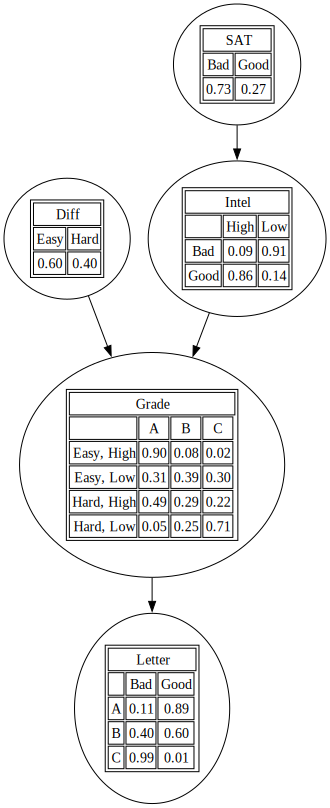

'student_pgm_with_cpt.pdf'

In [56]:
# Do the same for the hill climb model

network2 = DiscreteBayesianNetwork(best_hill_model)
mle = MaximumLikelihoodEstimator(network2, data)

# estimate the CPDs of the model and add to the model

for cpd in mle.get_parameters():
    network2.add_cpds(cpd)

dot = pgm.visualize_model(network2)
display(dot)
dot.render("student_pgm_with_cpt", format="pdf")

## Comparing Models

In [ ]:
# Compare the BIC score of the two learned structures on the data.
# BIC penalizes model complexity, so lower (more negative) = worse fit; higher = better.
# pgmpy >= 1.1: structure_score is a module, use get_scoring_method instead.

scorer = get_scoring_method('bic-d', data)
hill_score = scorer.score(network)
exh_score  = scorer.score(network2)

print(f"Exhaustive (BIC): {exh_score:.2f}")
print(f"HillClimb  (BIC): {hill_score:.2f}")
print()
print("Higher score = better structure given the data.")
print("If the scores differ, the algorithms found different DAGs.")